# Uncertainty-aware inverse design of a nonisothermal catalyst pellet

This commit-stamped tutorial validates and optimizes one spherical CO2-methanation pellet. It uses the published Koschany four-species kinetics and particle-scale values anchored to Zimmermann, Bremer, and Sundmacher, while labeling all transport and film data that are tutorial assumptions. The primary route is one simultaneous JAX/POUNCE NLP; an independent nested state-solve route checks it.

This is a **synthetic-calibration, activity-only, single-pellet study**. It is not an experimental fit, reactor co-design, or global-optimality claim. The full equations, units, source map, and limitations are in [`docs/src/catalyst-pellet.md`](../../docs/src/catalyst-pellet.md).

In [1]:
%matplotlib inline
from pathlib import Path
import platform, subprocess, sys, time

repo_root = Path.cwd()
if not (repo_root / 'python' / 'pounce').is_dir():
    repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / 'python'))

import jax
import matplotlib.pyplot as plt
import numpy as np
import scipy
import pounce
from dataclasses import replace
from pounce.examples.catalyst_pellet import (
    PelletConfig, Scenario, analytical_effectiveness, egg_shell_activity,
    fit_effective_parameters, implicit_observable_jacobian,
    refine_solution, solve_design, solve_first_order_sphere,
    solve_forward, solve_nested_design, uncertainty_scenarios,
    validate_uncertainty,
)

SOURCE_COMMIT = subprocess.check_output(
    ['git', 'rev-parse', 'HEAD'], cwd=repo_root, text=True
).strip()
MODEL_REVISION = 'catalyst-pellet-v1'
print(f'source commit: {SOURCE_COMMIT}')
print(f'model revision: {MODEL_REVISION}')
print(f'Python {platform.python_version()} | pounce {pounce.__version__}')
print(f'numpy {np.__version__} | scipy {scipy.__version__} | jax {jax.__version__}')
print(f'platform {platform.platform()} [{platform.machine()}] | '
      f'backend={jax.default_backend()}')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


source commit: 13960fdf69566efac3dfcac4f66915b52dd7e7e4
model revision: catalyst-pellet-v1
Python 3.13.5 | pounce 0.10.0
numpy 2.5.0 | scipy 1.17.1 | jax 0.9.2
platform Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39 [x86_64] | backend=cpu


## 1. Model contract before optimization

Published anchors: 2.5 mm particle diameter, 5 bar, 0.2 CO2 / 0.8 H2, 4500 kg m^-3 solid density, 2.5 W m^-1 K^-1 conductivity, and the Koschany kinetic constants. We use 555 K (the kinetic reference temperature) rather than reproduce the source paper's axial reactor inlet. Porosity, effective diffusivities, external films, heat of reaction, catalyst inventory, and regularization are explicit assumptions. The 613 K ceiling is the top of the published kinetic range and is stricter than Zimmermann's particle-design ceiling.

In [2]:
config = PelletConfig(nodes=8, zones=4)
print('mesh / activity zones:', config.nodes, '/', config.zones)
print('solver tolerances: forward 1e-11; design tol 1e-7; acceptable 1e-6')
print('radius [m], pressure [bar], bulk T [K]:',
      config.radius_m, config.pressure_bar, config.bulk_temperature_k)
print('D_eff [m^2/s]:', config.effective_diffusivities_m2_s)
print('mass films [m/s], heat film [W/m^2/K]:',
      config.mass_transfer_coefficients_m_s,
      config.heat_transfer_coefficient_w_m2_k)
print('inventory / upper bound / regularization:',
      config.activity_inventory, config.activity_upper,
      config.regularization_weight)

mesh / activity zones: 8 / 4
solver tolerances: forward 1e-11; design tol 1e-7; acceptable 1e-6
radius [m], pressure [bar], bulk T [K]: 0.00125 5.0 555.0
D_eff [m^2/s]: (1e-06, 2.8e-06, 1.2e-06, 1.1e-06)
mass films [m/s], heat film [W/m^2/K]: (0.08, 0.14, 0.09, 0.09) 250.0
inventory / upper bound / regularization: 0.16 1.0 0.5


## 2. Analytical limit and conservative uniform pellet

The equal-volume sphere has a zero-area center face, so center symmetry is exact and no numerical `1/r` is evaluated. First we compare its first-order isothermal effectiveness factor with `3/phi (coth(phi) - 1/phi)`.

In [3]:
print('phi    analytical       finite-volume    relative error    balance')
sphere_relative_errors = []
sphere_balance_errors = []
for phi in (0.0, 0.1, 1.0, 10.0):
    eta_fv, _, _, balance = solve_first_order_sphere(phi, nodes=160)
    eta_exact = analytical_effectiveness(phi)
    relative = abs(eta_fv - eta_exact) / max(abs(eta_exact), 1e-15)
    sphere_relative_errors.append(relative)
    sphere_balance_errors.append(balance)
    print(f'{phi:4.1f}  {eta_exact:14.10f}  {eta_fv:14.10f}  '
          f'{relative:14.3e}  {balance:9.2e}')

phi    analytical       finite-volume    relative error    balance
 0.0    1.0000000000    1.0000000000       0.000e+00   0.00e+00
 0.1    0.9993339676    0.9993339631       4.508e-09   1.25e-10
 1.0    0.9391058565    0.9391054079       4.777e-07   2.26e-12
10.0    0.2700000012    0.2699865354       4.987e-05   1.26e-13


In [4]:
uniform_activity = np.full(config.zones, config.activity_inventory)
uniform = solve_forward(uniform_activity, config)
uniform_refined = refine_solution(uniform, config, nodes=12)
slow_film_config = replace(
    config, mass_transfer_coefficients_m_s=(0.008,) * 4
)
film_limited = solve_forward(uniform_activity, slow_film_config)
print('case          nodes  production [mol/s]  Tmax [K]   max R     species bal  energy bal')
for name, solution in [
    ('uniform', uniform), ('refined', uniform_refined),
    ('slow film', film_limited),
]:
    print(f'{name:12s} {solution.radius_m.size:5d}  '
          f'{solution.production_mol_s:18.10e}  '
          f'{solution.max_temperature_k:8.3f}  '
          f'{solution.max_scaled_residual:8.1e}  '
          f'{np.max(solution.species_balance_relative):11.1e}  '
          f'{solution.energy_balance_relative:10.1e}')
print('coarse-to-refined production change [%]:',
      100 * (uniform_refined.production_mol_s / uniform.production_mol_s - 1))
print('coarse-to-refined Tmax change [K]:',
      uniform_refined.max_temperature_k - uniform.max_temperature_k)

case          nodes  production [mol/s]  Tmax [K]   max R     species bal  energy bal
uniform          8    5.0094780799e-07   572.509   7.4e-14      6.1e-15     2.4e-15
refined         12    5.0115536637e-07   572.543   3.7e-13      1.9e-14     8.4e-16
slow film        8    4.2018959471e-07   569.692   2.5e-13      5.4e-15     5.4e-15
coarse-to-refined production change [%]: 0.04143313414015637
coarse-to-refined Tmax change [K]: 0.03378951180047807


## 3. Exact design derivatives and transcription choice

For fixed activity, `R(s,a)=0`. JAX differentiates the finite-volume residual and the nested route uses `ds/dq = -R_s^-1 R_q`. We compare signed production and hot-spot derivatives for every activity zone and both uncertain log parameters with full central perturb-and-resolve calculations, not with a fixture built from the derivative formula.

In [5]:
exact = implicit_observable_jacobian(uniform, config)
epsilon = 1e-5
columns = []
for j in range(config.zones):
    plus, minus = uniform_activity.copy(), uniform_activity.copy()
    plus[j] += epsilon; minus[j] -= epsilon
    sp = solve_forward(plus, config, initial_state=uniform.state_scaled)
    sm = solve_forward(minus, config, initial_state=uniform.state_scaled)
    columns.append((
        np.array([sp.production_mol_s, sp.max_temperature_k])
        - np.array([sm.production_mol_s, sm.max_temperature_k])
    ) / (2 * epsilon))
finite_difference = np.stack(columns, axis=1)
relative_error = np.abs(exact - finite_difference) / np.maximum(
    np.abs(finite_difference), 1e-15
)
print('exact Jacobian [production; Tmax]:\n', exact)
print('full perturb-and-resolve Jacobian:\n', finite_difference)
print('maximum activity-gradient relative errors:', relative_error.max(axis=1))

scenario_exact = implicit_observable_jacobian(
    uniform, config, with_respect_to='scenario'
)
scenario_columns = []
for j in range(2):
    displacement = np.zeros(2); displacement[j] = epsilon
    sp = solve_forward(
        uniform_activity, config, scenario=Scenario(*displacement),
        initial_state=uniform.state_scaled,
    )
    sm = solve_forward(
        uniform_activity, config, scenario=Scenario(*(-displacement)),
        initial_state=uniform.state_scaled,
    )
    scenario_columns.append((
        np.array([sp.production_mol_s, sp.max_temperature_k])
        - np.array([sm.production_mol_s, sm.max_temperature_k])
    ) / (2 * epsilon))
scenario_finite_difference = np.stack(scenario_columns, axis=1)
scenario_relative_error = np.abs(
    scenario_exact - scenario_finite_difference
) / np.maximum(np.abs(scenario_finite_difference), 1e-15)
print('signed scenario Jacobian [log rate, log CO2 diffusivity]:\n',
      scenario_exact)
print('scenario full perturb-and-resolve Jacobian:\n',
      scenario_finite_difference)
print('maximum scenario-gradient relative errors:',
      scenario_relative_error.max(axis=1))

exact Jacobian [production; Tmax]:
 [[7.30477319e-07 1.01737058e-06 1.27657544e-06 1.53319636e-06]
 [2.68427189e+01 3.53132008e+01 4.36922018e+01 5.21369960e+01]]
full perturb-and-resolve Jacobian:
 [[7.30477319e-07 1.01737058e-06 1.27657544e-06 1.53319636e-06]
 [2.68427189e+01 3.53132008e+01 4.36922018e+01 5.21369960e+01]]
maximum activity-gradient relative errors: [4.22505783e-10 4.42079535e-10]


signed scenario Jacobian [log rate, log diffusivity]:
 [[7.29219151e-07 1.56012770e-07]
 [2.52776188e+01 5.54518330e+00]]
scenario full perturb-and-resolve Jacobian:
 [[7.29219151e-07 1.56012770e-07]
 [2.52776188e+01 5.54518330e+00]]
maximum scenario-gradient relative errors: [2.10779418e-10 8.58178954e-10]


In [6]:
started = time.perf_counter()
simultaneous = solve_design(config)
simultaneous_time = time.perf_counter() - started
started = time.perf_counter()
nested = solve_nested_design(config)
nested_time = time.perf_counter() - started
second_start = solve_design(config, initial_activity=egg_shell_activity(config))
print('route          success  iterations  wall [s]  max violation')
print(f'simultaneous  {simultaneous.success!s:7s}  {simultaneous.iterations:10d}  '
      f'{simultaneous_time:8.3f}  {simultaneous.max_constraint_violation:13.2e}')
print(f'nested        {nested.success!s:7s}  {nested.iterations:10d}  '
      f'{nested_time:8.3f}  {nested.max_constraint_violation:13.2e}')
print('simultaneous activity:', simultaneous.activity)
print('nested activity:      ', nested.activity)
print('second-start activity:', second_start.activity)
print('max simultaneous/nested activity difference:',
      np.max(np.abs(simultaneous.activity - nested.activity)))
print('max two-start activity difference:',
      np.max(np.abs(simultaneous.activity - second_start.activity)))

route          success  iterations  wall [s]  max violation
simultaneous  True             10     3.105       1.49e-13
nested        True              5     0.339       0.00e+00
simultaneous activity: [2.95978459e-11 4.73696955e-11 1.26756994e-01 5.13243006e-01]
nested activity:       [3.68015081e-18 1.42443100e-18 1.26756557e-01 5.13243443e-01]
second-start activity: [2.97072212e-11 4.72339098e-11 1.26756994e-01 5.13243006e-01]
max simultaneous/nested activity difference: 4.3699419027820596e-07
max two-start activity difference: 4.828359934094806e-12


The routes agree, but the simultaneous transcription is the tutorial route: POUNCE sees every state bound, balance, inventory equation, and thermal limit in one NLP. The nested route is valuable as an independent algorithm and derivative check. Timings include cached JAX compilation state and are descriptive for this recorded environment, not a general benchmark.

## 4. Equal-inventory designs and independent mesh refinement

The ideal egg-shell fills the outermost volume first. The optimized design pays a fixed quadratic jump penalty, so it should be smoother and may give up some production. Classical bounded-loading work predicts step-like profiles; no global optimum is claimed.

design       activity                              production [mol/s]  Tmax [K]  roughness
uniform     [0.16 0.16 0.16 0.16]                    5.0115536637e-07   572.543     0.0000
egg-shell   [0.   0.   0.   0.64]                    7.6614625385e-07   580.744     0.4096
optimized   [2.9598e-11 4.7370e-11 1.2676e-01 5.1324e-01]   7.2959043470e-07   579.589     0.1654
optimized refinement changes: production [%], Tmax [K] = 0.5760041319711862 0.1422272265377842


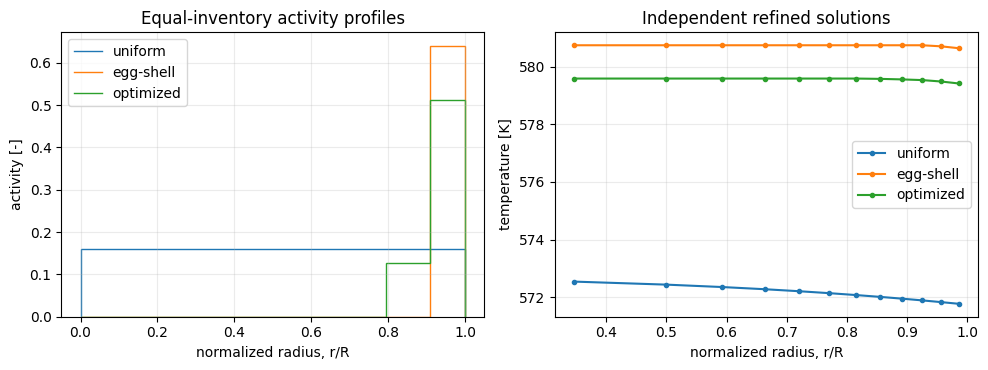

In [7]:
egg_activity = egg_shell_activity(config)
egg = solve_forward(egg_activity, config)
optimized_refined = refine_solution(simultaneous.nominal, config, nodes=12)
egg_refined = refine_solution(egg, config, nodes=12)
print('design       activity                              production [mol/s]  Tmax [K]  roughness')
for name, activity, solution in [
    ('uniform', uniform_activity, uniform_refined),
    ('egg-shell', egg_activity, egg_refined),
    ('optimized', simultaneous.activity, optimized_refined),
]:
    print(f'{name:11s} {np.array2string(activity, precision=4):38s} '
          f'{solution.production_mol_s:18.10e}  '
          f'{solution.max_temperature_k:8.3f}  '
          f'{np.sum(np.diff(activity)**2):9.4f}')
print('optimized refinement changes: production [%], Tmax [K] =',
      100 * (optimized_refined.production_mol_s
             / simultaneous.nominal.production_mol_s - 1),
      optimized_refined.max_temperature_k
      - simultaneous.nominal.max_temperature_k)

zone_faces = np.linspace(0.0, 1.0, config.zones + 1) ** (1.0 / 3.0)
designs = [
    ('uniform', uniform_activity, uniform_refined),
    ('egg-shell', egg_activity, egg_refined),
    ('optimized', simultaneous.activity, optimized_refined),
]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for name, activity, solution in designs:
    axes[0].stairs(activity, zone_faces, label=name)
    axes[1].plot(
        solution.radius_m / config.radius_m, solution.temperature_k,
        marker='o', ms=3, label=name,
    )
axes[0].set(xlabel='normalized radius, r/R', ylabel='activity [-]',
            title='Equal-inventory activity profiles')
axes[1].set(xlabel='normalized radius, r/R', ylabel='temperature [K]',
            title='Independent refined solutions')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
plt.show()

Zimmermann et al. found an active **core** with an inert low-permeability shell while also optimizing permeability, conductivity, and reactor operation. This activity-only prescribed-bulk model instead favors outer activity. The near-step structure agrees qualitatively with bounded-loading theory, but the opposite placement is an important model-form difference, not a claimed reproduction of the coupled reactor optimum.

## 5. Synthetic calibration, covariance, and uncertainty propagation

Synthetic log-rate data combine intrinsic powder observations with apparent rates at two pellet radii. POUNCE fits log multipliers for intrinsic rate and CO2 diffusivity and obtains covariance from its reduced Hessian. Principal-axis scenarios use 1.645 standard deviations. Delta-method uncertainty is checked against full sampled nonlinear re-solves.

In [8]:
fit = fit_effective_parameters(config=config)
scenarios = uncertainty_scenarios(fit.popt, fit.pcov)
validation = validate_uncertainty(
    simultaneous.activity, fit.popt, fit.pcov, config, samples=16, seed=103
)
print('fit success / covariance route:', fit.success, '/', fit.cov_source)
print('parameters [log rate, log diffusivity]:', fit.popt)
print('standard errors:', fit.perr)
print('correlation:\n', fit.correlation)
print('observable          nominal          delta sd        sampled sd      ratio')
for i, name in enumerate(validation.observable_names):
    print(f'{name:20s} {validation.nominal[i]:14.6e}  '
          f'{validation.delta_standard_deviation[i]:14.6e}  '
          f'{validation.sampled_standard_deviation[i]:14.6e}  '
          f'{validation.sampled_standard_deviation[i] / validation.delta_standard_deviation[i]:7.3f}')
print('sampled Tmax range [K]:',
      validation.sampled_minimum[1], validation.sampled_maximum[1])

fit success / covariance route: True / reduced_hessian
parameters [log rate, log diffusivity]: [-0.00269047  0.00591682]
standard errors: [0.00453405 0.01560521]
correlation:
 [[ 1.         -0.57986711]
 [-0.57986711  1.        ]]
observable          nominal          delta sd        sampled sd      ratio
production_mol_s       7.201802e-07    9.076583e-09    1.101646e-08    1.214
max_temperature_k      5.792705e+02    3.057933e-01    3.711406e-01    1.214
sampled Tmax range [K]: 578.7148062034213 579.9502234059139


## 6. Scenario-based worst-case redesign

All covariance scenarios share one activity profile. An epigraph variable is constrained below every scenario production, and POUNCE maximizes that finite-set guarantee minus the same manufacturability penalty. It is not a distribution-free guarantee.

In [9]:
fitted_nominal = solve_design(config, scenarios=(scenarios[0],))
robust = solve_design(
    config, scenarios=scenarios, robust=True,
    initial_activity=fitted_nominal.activity,
)
nominal_scenario_solutions = [
    solve_forward(fitted_nominal.activity, config, scenario=scenario)
    for scenario in scenarios
]
print('nominal activity:', fitted_nominal.activity)
print('robust activity: ', robust.activity)
print('scenario             nominal design [mol/s]  robust design [mol/s]  robust Tmax [K]')
for scenario, nominal_solution, robust_solution in zip(
    scenarios, nominal_scenario_solutions, robust.solutions
):
    print(f'{scenario.label:20s} {nominal_solution.production_mol_s:22.10e}  '
          f'{robust_solution.production_mol_s:21.10e}  '
          f'{robust_solution.max_temperature_k:14.3f}')
scenario_reference = np.mean([
    solve_forward(uniform_activity, config, scenario=scenario).production_mol_s
    for scenario in scenarios
])
nominal_score = (
    min(solution.production_mol_s for solution in nominal_scenario_solutions)
    / scenario_reference
    - config.regularization_weight * np.sum(np.diff(fitted_nominal.activity)**2)
)
robust_score = (
    min(solution.production_mol_s for solution in robust.solutions)
    / scenario_reference
    - config.regularization_weight * np.sum(np.diff(robust.activity)**2)
)
print('enforced finite-scenario production floor [mol/s]:',
      robust.guaranteed_production_mol_s)
print('observed minimum over scenario re-solves [mol/s]:',
      min(solution.production_mol_s for solution in robust.solutions))
print('worst-case regularized score, nominal / robust:',
      nominal_score, '/', robust_score)
print('maximum robust-scenario temperature [K]:',
      max(solution.max_temperature_k for solution in robust.solutions),
      '<', config.temperature_limit_k)

nominal activity: [3.05527996e-11 5.06584011e-11 1.29901624e-01 5.10098376e-01]
robust activity:  [3.28590084e-11 5.96467612e-11 1.36675050e-01 5.03324950e-01]
scenario             nominal design [mol/s]  robust design [mol/s]  robust Tmax [K]
nominal                    7.1919284764e-07       7.1704071865e-07         579.170
principal-1+               7.0616991790e-07       7.0416656097e-07         578.736
principal-1-               7.3292072622e-07       7.3059923115e-07         579.627
principal-2+               7.1272707339e-07       7.1069636141e-07         578.957
principal-2-               7.2563567182e-07       7.2335630756e-07         579.383
enforced finite-scenario production floor [mol/s]: 7.041665609630597e-07
observed minimum over scenario re-solves [mol/s]: 7.041665609680437e-07
worst-case regularized score, nominal / robust: 1.3319173637560227 / 1.3320657201832835
maximum robust-scenario temperature [K]: 579.6271782542922 < 613.0


## 7. Verification

The checks below collect the analytical, physical, derivative, optimization, refinement, covariance, and robust-design evidence used throughout the tutorial. They are deliberately evaluated from the solved objects above rather than from a second set of copied expected values.

In [10]:
sample_ratio = (
    validation.sampled_standard_deviation
    / validation.delta_standard_deviation
)
observed_robust_floor = min(
    solution.production_mol_s for solution in robust.solutions
)
reported_activities = (
    uniform_activity, egg_activity, simultaneous.activity,
    fitted_nominal.activity, robust.activity,
)
verification = {
    'analytical sphere': (
        max(sphere_relative_errors) < 6e-5
        and max(sphere_balance_errors) < 2e-8
    ),
    'uniform balances and films': (
        uniform.success
        and uniform.max_scaled_residual < 1e-10
        and np.max(uniform.species_balance_relative) < 1e-10
        and uniform.energy_balance_relative < 1e-10
        and film_limited.production_mol_s < uniform.production_mol_s
    ),
    'signed activity gradients': np.max(relative_error) < 2e-6,
    'signed scenario gradients': np.max(scenario_relative_error) < 2e-6,
    'nested/simultaneous agreement': (
        simultaneous.success and nested.success
        and np.allclose(
            simultaneous.activity, nested.activity, rtol=8e-4, atol=3e-6
        )
    ),
    'activity bounds and inventory': all(
        np.min(activity) >= -1e-8
        and np.max(activity) <= config.activity_upper + 1e-8
        and abs(np.mean(activity) - config.activity_inventory) < 1e-9
        for activity in reported_activities
    ),
    'second-start agreement': (
        second_start.success
        and np.allclose(
            simultaneous.activity, second_start.activity,
            rtol=1e-5, atol=1e-7,
        )
    ),
    'independent mesh refinement': (
        optimized_refined.success
        and abs(
            optimized_refined.production_mol_s
            / simultaneous.nominal.production_mol_s - 1.0
        ) < 0.015
        and optimized_refined.max_temperature_k < config.temperature_limit_k
    ),
    'covariance and sampled re-solves': (
        fit.success and fit.cov_source == 'reduced_hessian'
        and np.all(np.linalg.eigvalsh(fit.pcov) > 0.0)
        and np.all((sample_ratio > 0.4) & (sample_ratio < 2.5))
        and validation.sampled_maximum[1] < config.temperature_limit_k
    ),
    'robust epigraph and thermal limit': (
        robust.success
        and np.isclose(
            robust.guaranteed_production_mol_s, observed_robust_floor,
            rtol=2e-8,
        )
        and robust_score > nominal_score
        and all(
            solution.max_temperature_k < config.temperature_limit_k
            for solution in robust.solutions
        )
    ),
}
for name, passed in verification.items():
    print(f'{name:36s} {"PASS" if passed else "FAIL"}')
assert all(verification.values())
print(f'all {len(verification)} checks passed')

analytical sphere                    PASS
uniform balances and films           PASS
signed activity gradients            PASS
signed scenario gradients            PASS
nested/simultaneous agreement        PASS
activity bounds and inventory        PASS
second-start agreement               PASS
independent mesh refinement          PASS
covariance and sampled re-solves     PASS
robust epigraph and thermal limit    PASS
all 10 checks passed


## 8. When to reach for which

| Situation | Use | What happened here |
|---|---|---|
| Validate a pellet state or a reported design | conservative forward solve on an independent mesh | Closed species/energy balances and kept the refined temperature below the kinetic ceiling |
| Expose state, inventory, and thermal constraints directly | simultaneous JAX/POUNCE NLP | Produced the reported activity profile and agreed with an independent nested optimizer |
| Check a small differentiable design calculation | nested fixed-mesh solve plus implicit derivatives | Matched signed full perturb-and-resolve derivatives and the simultaneous design |
| Quantify local parameter uncertainty | reduced-Hessian covariance plus sampled re-solves | Delta-method and sampled standard deviations agreed near the fitted point |
| Protect against a bounded finite uncertainty set | scenario epigraph design | Improved the worst-case regularized score while satisfying every scenario temperature limit |

### Four takeaways

**Validate before optimizing.** The analytical sphere, center treatment, films, balances, and mesh refinement establish the forward model before the activity profile is allowed to move.

**Keep the physical constraints visible.** The simultaneous transcription is the primary route because POUNCE sees the state bounds, catalyst inventory, and thermal ceiling in one NLP.

**Check derivatives by re-solving the physics.** Both activity and uncertain-parameter Jacobians are compared with signed central perturbations of complete forward solves.

**Separate local uncertainty from global claims.** The covariance, sampled re-solves, and finite scenarios describe a neighborhood of this fitted model; they do not certify every possible pellet or parameter distribution.

### Limits

The recommended profile is only a **local optimum of this model and this activity basis**. Assumed transport data and omitted reactor/pore physics are model-form uncertainty. The covariance is local and synthetic, and the principal-axis set is finite. No claim is made about a globally optimal pellet architecture, experimental robustness, permeability or conductivity design, transient operation, or a dead core.

### See also

- [Catalyst-pellet model, equations, and source map](../../docs/src/catalyst-pellet.md)
- [`26_parameter_covariance.ipynb`](26_parameter_covariance.ipynb) — reduced-Hessian covariance
- [`31_information_identifiability.ipynb`](31_information_identifiability.ipynb) — information and identifiability diagnostics
- [Boundary Value Problems](../../docs/src/bvp.md) — constrained and differentiable BVP routes